# 🎫 Customer Support Ticket Classification & Priority Assignment

An end-to-end NLP pipeline that **classifies** customer support tickets into categories and **assigns priority** levels automatically.

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Generation & EDA](#2)
3. [Text Preprocessing](#3)
4. [Feature Extraction (TF-IDF vs BoW)](#4)
5. [Model Training & Comparison](#5)
6. [Model Evaluation & Visualizations](#6)
7. [Priority Assignment](#7)
8. [Prediction Function & Test Cases](#8)
9. [Save Model & Export Predictions](#9)

<a id='1'></a>
## 1. Setup & Imports

In [1]:
# Core
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# NLP
import nltk

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Project modules
from src.dataset import generate_dataset, save_dataset
from src.preprocessing import preprocess, preprocess_series
from src.feature_extraction import build_tfidf, build_bow
from src.models import get_models, train_model, evaluate_model, compare_models, select_best_model
from src.priority import rule_based_priority, train_priority_model, evaluate_priority_model
from src.visualizations import (
    plot_category_distribution, plot_priority_distribution,
    plot_confusion_matrix, plot_model_comparison, plot_text_length_distribution
)
from src.predictor import predict_ticket, save_artifacts, export_predictions, predict_batch

print('All imports successful!')

All imports successful!


<a id='2'></a>
## 2. Dataset Generation & Exploratory Data Analysis

We generate **1,000 synthetic tickets** across four categories:
- Technical Issue
- Billing Issue
- Account Access
- General Inquiry

Each ticket also has a **priority** label (High / Medium / Low) assigned via keyword rules.

In [2]:
# Generate the synthetic dataset
df = generate_dataset(n_samples=1000, seed=42)
save_dataset(df, 'data/tickets.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset shape: (1000, 4)
Columns: ['ticket_id', 'text', 'category', 'priority']


,ticket_id,text,category,priority
0,TKT-0001,My application keeps crashing every time I try...,Technical Issue,Medium
1,TKT-0002,I need to update my payment method on file. Co...,Billing Issue,Medium
2,TKT-0003,The website shows a 404 error on multiple page...,Technical Issue,High
3,TKT-0004,The app crashes immediately on startup with a ...,Technical Issue,High
4,TKT-0005,Payment gateway keeps rejecting my valid credi...,Billing Issue,Medium
5,TKT-0006,What integrations are available with other too...,General Inquiry,Low
6,TKT-0007,The calendar sync is broken between devices. C...,Technical Issue,High
7,TKT-0008,Are there any upcoming features on the product...,General Inquiry,Low
8,TKT-0009,This is critical — Someone may have hacked int...,Account Access,High
9,TKT-0010,My account has been locked after multiple fail...,Account Access,High


Category Distribution:
category
Technical Issue    259
Account Access     254
Billing Issue      249
General Inquiry    238
Name: count, dtype: int64


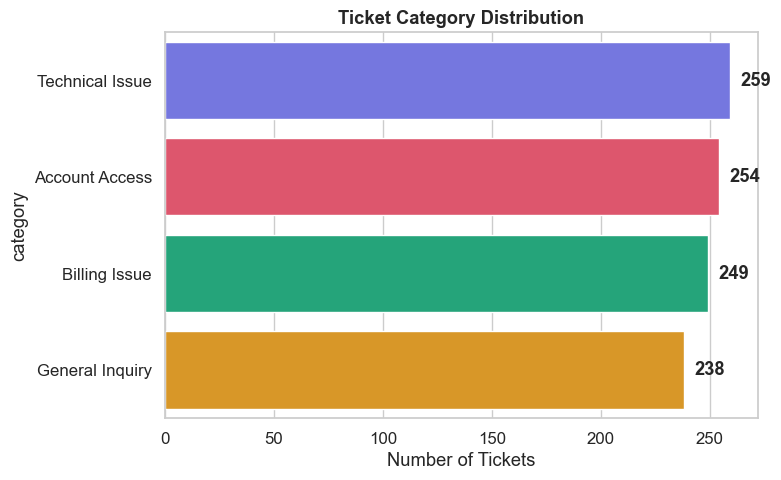

In [3]:
# Category distribution
print('Category Distribution:')
print(df['category'].value_counts())
plot_category_distribution(df)
plt.show()

Priority Distribution:
priority
Medium    476
High      313
Low       211
Name: count, dtype: int64


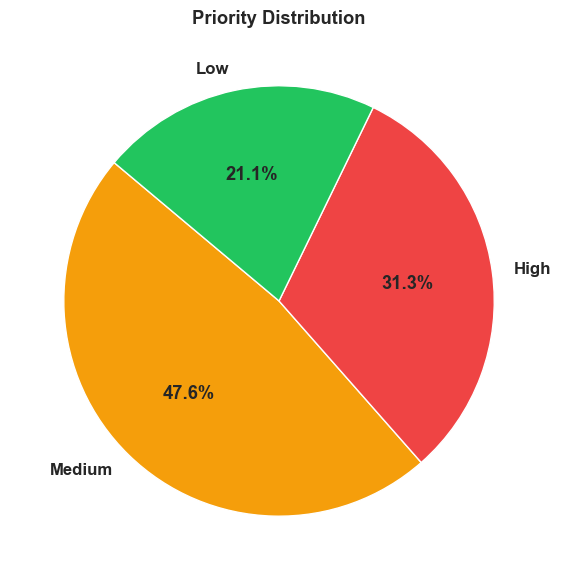

In [4]:
# Priority distribution
print('Priority Distribution:')
print(df['priority'].value_counts())
plot_priority_distribution(df)
plt.show()

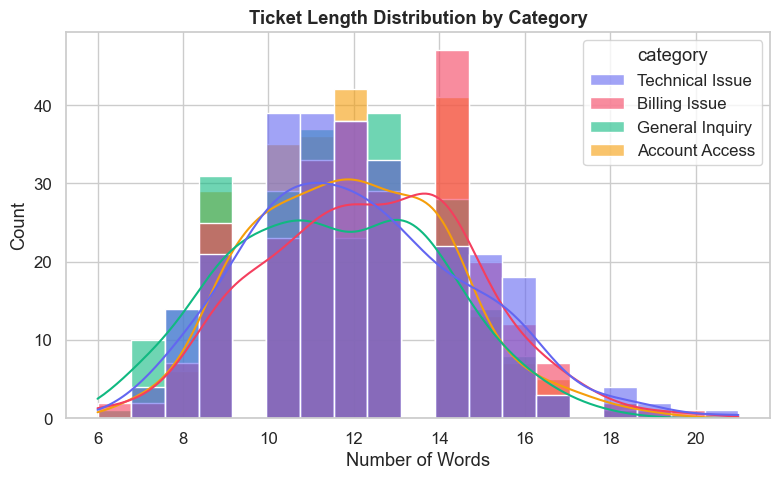

In [5]:
# Text length analysis
plot_text_length_distribution(df)
plt.show()

<a id='3'></a>
## 3. Text Preprocessing

Our preprocessing pipeline (implemented in `src/preprocessing.py`) applies these steps:

| Step | Operation |
|------|-----------|
| 1 | Convert to lowercase |
| 2 | Remove punctuation & special characters |
| 3 | Tokenization (NLTK `word_tokenize`) |
| 4 | Stopword removal |
| 5 | Lemmatization (`WordNetLemmatizer`) |

In [6]:
# Show step-by-step preprocessing on a sample ticket
from src.preprocessing import to_lowercase, remove_punctuation, tokenize, remove_stopwords, lemmatize

sample = df['text'].iloc[0]
print(f'Original:        {sample}')
step1 = to_lowercase(sample)
print(f'Lowercase:       {step1}')
step2 = remove_punctuation(step1)
print(f'No punctuation:  {step2}')
step3 = tokenize(step2)
print(f'Tokens:          {step3}')
step4 = remove_stopwords(step3)
print(f'No stopwords:    {step4}')
step5 = lemmatize(step4)
print(f'Lemmatized:      {step5}')
print(f'Final string:    {" ".join(step5)}')

Original:        My application keeps crashing every time I try to open it. Thank you for your help.
Lowercase:       my application keeps crashing every time i try to open it. thank you for your help.
No punctuation:  my application keeps crashing every time i try to open it thank you for your help


Tokens:          ['my', 'application', 'keeps', 'crashing', 'every', 'time', 'i', 'try', 'to', 'open', 'it', 'thank', 'you', 'for', 'your', 'help']
No stopwords:    ['application', 'keeps', 'crashing', 'every', 'time', 'try', 'open', 'thank', 'help']


Lemmatized:      ['application', 'keep', 'crashing', 'every', 'time', 'try', 'open', 'thank', 'help']
Final string:    application keep crashing every time try open thank help


In [7]:
# Apply preprocessing to the entire dataset
df['cleaned_text'] = preprocess_series(df['text'])
print('Preprocessing complete!')
df[['text', 'cleaned_text']].head()

Preprocessing complete!


,text,cleaned_text
0,My application keeps crashing every time I try...,application keep crashing every time try open ...
1,I need to update my payment method on file. Co...,need update payment method file could help
2,The website shows a 404 error on multiple page...,website show 404 error multiple page thanks
3,The app crashes immediately on startup with a ...,app crash immediately startup fatal error plea...
4,Payment gateway keeps rejecting my valid credi...,payment gateway keep rejecting valid credit ca...


<a id='4'></a>
## 4. Feature Extraction

We compare two approaches:
- **TF-IDF Vectorization** (Term Frequency - Inverse Document Frequency) captures word importance
- **Bag of Words** (Count Vectorizer) uses raw word counts

Both use **unigrams + bigrams** with a max of 5,000 features.

In [8]:
# Encode labels
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Train/Test split (80/20)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'], df['category_encoded'],
    test_size=0.2, random_state=42, stratify=df['category_encoded']
)
print(f'\nTrain size: {len(X_train_text)},  Test size: {len(X_test_text)}')

Label mapping: {'Account Access': np.int64(0), 'Billing Issue': np.int64(1), 'General Inquiry': np.int64(2), 'Technical Issue': np.int64(3)}

Train size: 800,  Test size: 200


In [9]:
# TF-IDF
tfidf_vec, X_train_tfidf = build_tfidf(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)
print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

# Bag of Words
bow_vec, X_train_bow = build_bow(X_train_text)
X_test_bow = bow_vec.transform(X_test_text)
print(f'BoW matrix shape:    {X_train_bow.shape}')

TF-IDF matrix shape: (800, 1153)
BoW matrix shape:    (800, 1153)


<a id='5'></a>
## 5. Model Training & Comparison

We train three classifiers on the **TF-IDF** features and compare their performance.

In [10]:
# Train all models on TF-IDF features
models = get_models()
results = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    trained = train_model(model, X_train_tfidf, y_train)
    res = evaluate_model(trained, X_test_tfidf, y_test)
    results[name] = res
    results[name]['trained_model'] = trained
    print(f'   Accuracy: {res["accuracy"]:.4f}  |  F1: {res["f1"]:.4f}')

print('\nAll models trained!')


Training Logistic Regression...
   Accuracy: 0.9950  |  F1: 0.9950

Training Naive Bayes...
   Accuracy: 0.9800  |  F1: 0.9800

Training Random Forest...


   Accuracy: 1.0000  |  F1: 1.0000

All models trained!


In [11]:
# Comparison table
comparison_df = compare_models(results)
print('\nModel Comparison (TF-IDF):')
comparison_df


Model Comparison (TF-IDF):


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9950,0.9951,0.9950,0.9950
1,Naive Bayes,0.9800,0.9815,0.9800,0.9800
2,Random Forest,1.0000,1.0000,1.0000,1.0000


In [12]:
# Also train on BoW for comparison
bow_results = {}
for name, model_class in get_models().items():
    trained = train_model(model_class, X_train_bow, y_train)
    bow_results[name] = evaluate_model(trained, X_test_bow, y_test)

bow_comparison = compare_models(bow_results)
bow_comparison['Model'] = bow_comparison['Model'] + ' (BoW)'
comparison_df['Model'] = comparison_df['Model'] + ' (TF-IDF)'

# Combined comparison
full_comparison = pd.concat([comparison_df, bow_comparison], ignore_index=True)
print('\nFull Comparison - TF-IDF vs Bag of Words:')
full_comparison


Full Comparison - TF-IDF vs Bag of Words:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (TF-IDF),0.9950,0.9951,0.9950,0.9950
1,Naive Bayes (TF-IDF),0.9800,0.9815,0.9800,0.9800
2,Random Forest (TF-IDF),1.0000,1.0000,1.0000,1.0000
3,Logistic Regression (BoW),1.0000,1.0000,1.0000,1.0000
4,Naive Bayes (BoW),0.9800,0.9815,0.9800,0.9800
5,Random Forest (BoW),1.0000,1.0000,1.0000,1.0000


<a id='6'></a>
## 6. Model Evaluation & Visualizations

In [13]:
# Select best model
best_name = select_best_model(results)
best_result = results[best_name]
best_model = best_result['trained_model']
print(f'Best model: {best_name}  (F1={best_result["f1"]:.4f})')

# Detailed classification report
print(f'\nClassification Report - {best_name}:')
print(best_result['report'])

Best model: Random Forest  (F1=1.0000)

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        47
           3       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



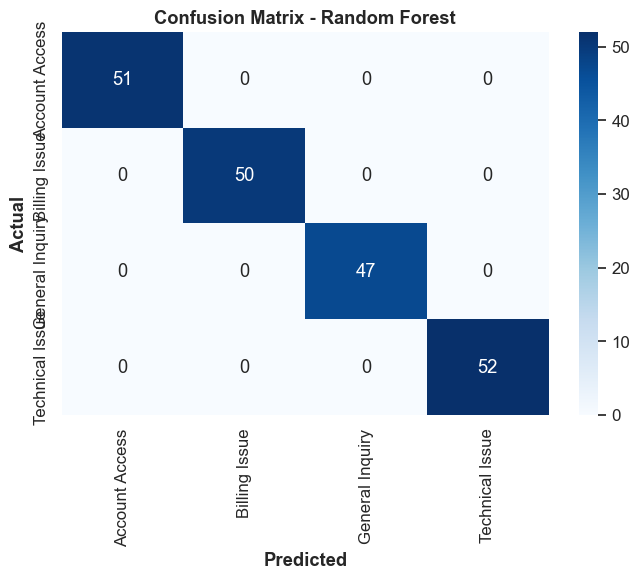

In [14]:
# Confusion matrix for the best model
plot_confusion_matrix(y_test, best_result['y_pred'], display_labels=le.classes_,
                      title=f'Confusion Matrix - {best_name}')
plt.show()

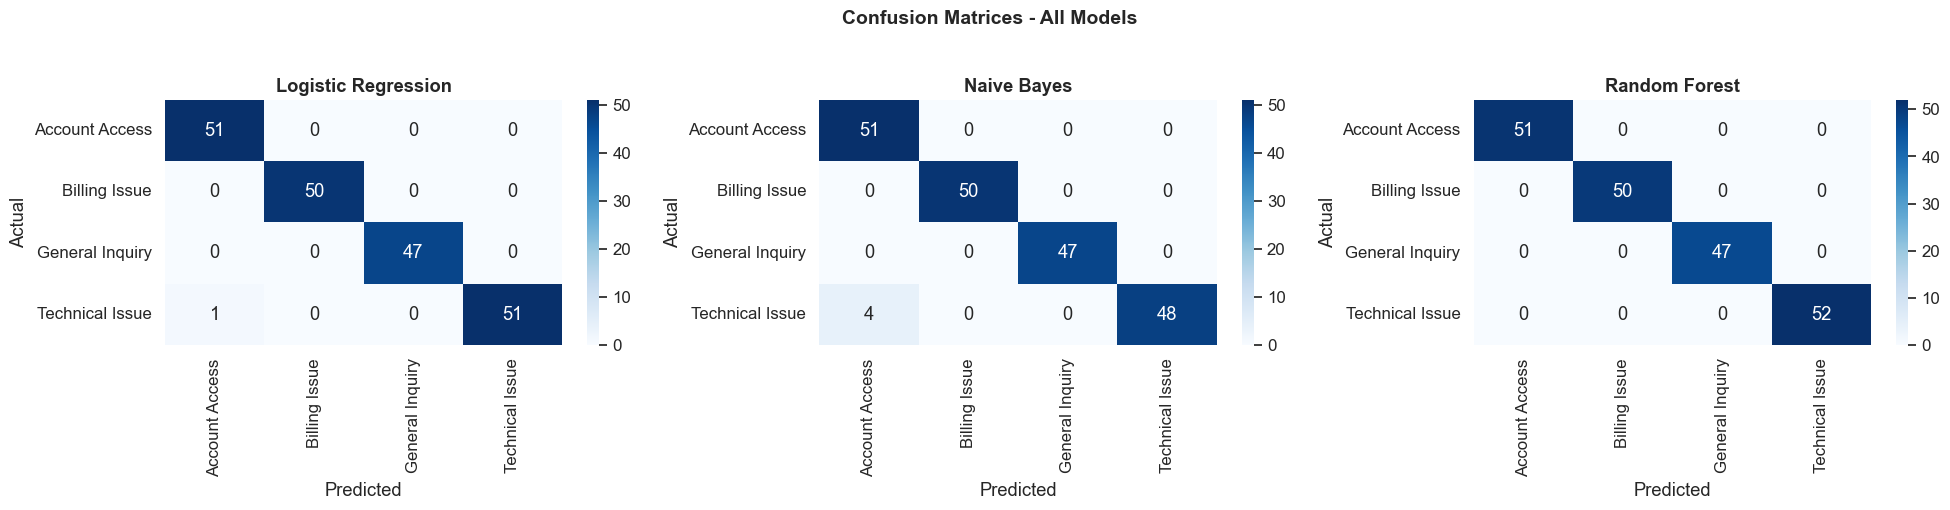

In [15]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (name, res) in zip(axes, results.items()):
    from sklearn.metrics import confusion_matrix as cm_func
    cm = cm_func(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices - All Models', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

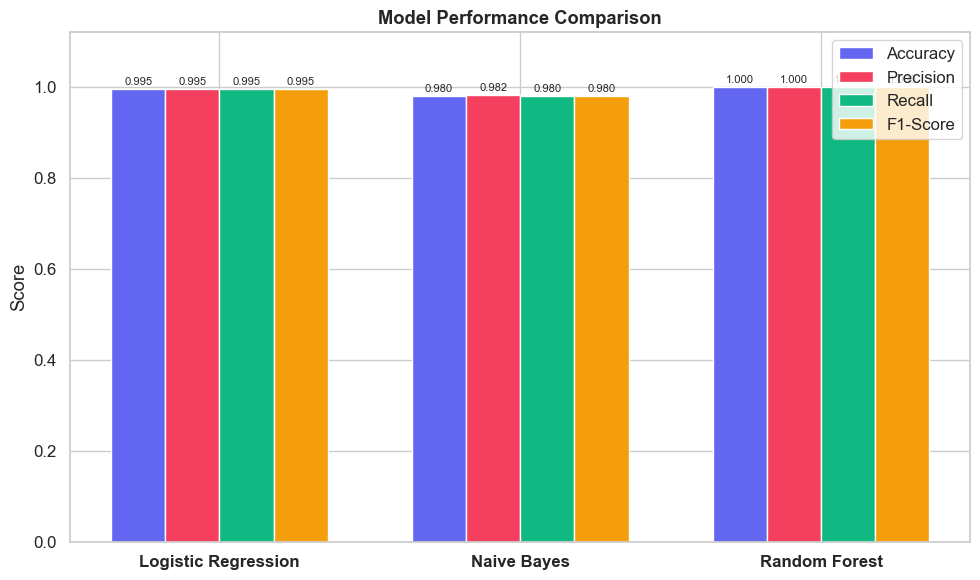

In [16]:
# Model performance comparison chart
chart_df = compare_models(results)
plot_model_comparison(chart_df)
plt.show()

<a id='7'></a>
## 7. Priority Assignment

We implement **two approaches**:

### 7a. Rule-Based Priority
| Priority | Condition |
|----------|-----------|
| **High** | Keywords: *urgent, error, failed, not working, immediately, critical, crashed, broken* |
| **Low** | Keywords: *information, pricing, plan, how do, features, trial, tutorial* |
| **Medium** | Everything else |

### 7b. Model-Based Priority
A Logistic Regression model trained on the same TF-IDF features to predict priority labels.

In [17]:
# 7a. Rule-based priority - verify on original data
df['predicted_priority_rule'] = df['text'].apply(rule_based_priority)

from sklearn.metrics import accuracy_score
rule_acc = accuracy_score(df['priority'], df['predicted_priority_rule'])
print(f'Rule-based priority accuracy: {rule_acc:.4f}')
print(pd.crosstab(df['priority'], df['predicted_priority_rule'], margins=True))

Rule-based priority accuracy: 0.8670
predicted_priority_rule  High  Low  Medium   All
priority                                        
High                      313    0       0   313
Low                        16  144      51   211
Medium                     29   37     410   476
All                       358  181     461  1000


In [18]:
# 7b. Model-based priority
le_priority = LabelEncoder()
df['priority_encoded'] = le_priority.fit_transform(df['priority'])

_, _, y_train_pri, y_test_pri = train_test_split(
    df['cleaned_text'], df['priority_encoded'],
    test_size=0.2, random_state=42, stratify=df['priority_encoded']
)

pri_model = train_priority_model(X_train_tfidf, y_train_pri)
pri_eval = evaluate_priority_model(pri_model, X_test_tfidf, y_test_pri)

print(f'Model-based priority accuracy: {pri_eval["accuracy"]:.4f}')
print(pri_eval['report'])

Model-based priority accuracy: 0.4050
              precision    recall  f1-score   support

           0       0.38      0.30      0.34        63
           1       0.05      0.02      0.03        42
           2       0.47      0.64      0.54        95

    accuracy                           0.41       200
   macro avg       0.30      0.32      0.30       200
weighted avg       0.35      0.41      0.37       200



<a id='8'></a>
## 8. Prediction Function & Test Cases

The `predict_ticket(text)` function returns `(category, priority)` for any raw ticket text.

In [19]:
# Save best model first so predict_ticket can load it
save_artifacts(best_model, tfidf_vec, le)

✅ Artifacts saved to 'saved_models/'


In [20]:
# --- Test Cases ---

test_tickets = [
    # Technical Issues
    "URGENT: My app crashed and I lost all my data!",
    "The software keeps freezing when I try to save files.",
    
    # Billing Issues
    "I was charged twice on my credit card this month.",
    "I need a refund immediately, the payment was unauthorized!",
    
    # Account Access
    "I can't log into my account, the password reset is broken.",
    "My account was locked and I need help getting back in.",
    
    # General Inquiry
    "What subscription plans do you offer?",
    "Do you have documentation available for the API?",
    
    # Edge cases
    "This is not working and I need it fixed immediately!",
    "Just wondering about your pricing.",
]

print('=' * 80)
print(f'{"TICKET TEXT":<55} {"CATEGORY":<20} {"PRIORITY"}')
print('=' * 80)

for ticket in test_tickets:
    category, priority = predict_ticket(ticket)
    short = ticket[:52] + '...' if len(ticket) > 55 else ticket
    print(f'{short:<55} {category:<20} {priority}')

print('=' * 80)

TICKET TEXT                                             CATEGORY             PRIORITY
URGENT: My app crashed and I lost all my data!          General Inquiry      High
The software keeps freezing when I try to save files.   Technical Issue      Medium


I was charged twice on my credit card this month.       Billing Issue        Medium
I need a refund immediately, the payment was unautho... Billing Issue        High


I can't log into my account, the password reset is b... Account Access       High


My account was locked and I need help getting back in.  Account Access       Medium
What subscription plans do you offer?                   General Inquiry      Low
Do you have documentation available for the API?        General Inquiry      Low
This is not working and I need it fixed immediately!    Technical Issue      High
Just wondering about your pricing.                      General Inquiry      Low


In [21]:
# Batch prediction
batch_df = predict_batch(test_tickets)
batch_df['text'] = test_tickets
batch_df = batch_df[['text', 'category', 'priority']]
batch_df

,text,category,priority
0,URGENT: My app crashed and I lost all my data!,General Inquiry,High
1,The software keeps freezing when I try to save...,Technical Issue,Medium
2,I was charged twice on my credit card this month.,Billing Issue,Medium
3,"I need a refund immediately, the payment was u...",Billing Issue,High
4,"I can't log into my account, the password rese...",Account Access,High
5,My account was locked and I need help getting ...,Account Access,Medium
6,What subscription plans do you offer?,General Inquiry,Low
7,Do you have documentation available for the API?,General Inquiry,Low
8,This is not working and I need it fixed immedi...,Technical Issue,High
9,Just wondering about your pricing.,General Inquiry,Low


<a id='9'></a>
## 9. Save Model & Export Predictions

- Model saved with **joblib** to `saved_models/`
- Predictions exported to `data/predictions.csv`

In [22]:
# Export test predictions to CSV
export_df = pd.DataFrame({
    'ticket_id': df.loc[X_test_text.index, 'ticket_id'].values,
    'original_text': df.loc[X_test_text.index, 'text'].values,
    'actual_category': le.inverse_transform(y_test),
    'predicted_category': le.inverse_transform(best_result['y_pred']),
    'actual_priority': df.loc[X_test_text.index, 'priority'].values,
    'predicted_priority': df.loc[X_test_text.index, 'text'].apply(rule_based_priority).values,
})

export_predictions(export_df, 'data/predictions.csv')
export_df.head(10)

✅ Predictions exported to 'data/predictions.csv'


,ticket_id,original_text,actual_category,predicted_category,actual_priority,predicted_priority
0,TKT-0717,I need this resolved ASAP. Do you provide onbo...,General Inquiry,General Inquiry,Low,High
1,TKT-0196,I want a refund for the service I did not use....,Billing Issue,Billing Issue,Medium,Medium
2,TKT-0896,Password reset token has expired before I coul...,Account Access,Account Access,Medium,Medium
3,TKT-0977,The annual billing amount is incorrect. Lookin...,Billing Issue,Billing Issue,Medium,Medium
4,TKT-0771,How do I get started with the platform? Thank ...,General Inquiry,General Inquiry,Low,Low
5,TKT-0694,How do I get started with the platform?,General Inquiry,General Inquiry,Low,Low
6,TKT-0814,What is the maximum file upload size allowed? ...,General Inquiry,General Inquiry,Low,Low
7,TKT-0299,Two-factor authentication codes are not being ...,Technical Issue,Technical Issue,Medium,Medium
8,TKT-0881,Subscription renewed without sending any remin...,Billing Issue,Billing Issue,Medium,Medium
9,TKT-0884,My free trial ended early and I was charged im...,Billing Issue,Billing Issue,High,High


In [23]:
# Summary statistics
print('\n' + '=' * 60)
print('   PROJECT SUMMARY')
print('=' * 60)
print(f'   Dataset size:         {len(df)} tickets')
print(f'   Categories:           {list(le.classes_)}')
print(f'   Best model:           {best_name}')
print(f'   Best F1-Score:        {best_result["f1"]:.4f}')
print(f'   Best Accuracy:        {best_result["accuracy"]:.4f}')
print(f'   Rule-based priority:  {rule_acc:.4f} accuracy')
print(f'   Model saved to:       saved_models/')
print(f'   Predictions saved to: data/predictions.csv')
print('=' * 60)
print('\nPipeline complete!')


   PROJECT SUMMARY
   Dataset size:         1000 tickets
   Categories:           ['Account Access', 'Billing Issue', 'General Inquiry', 'Technical Issue']
   Best model:           Random Forest
   Best F1-Score:        1.0000
   Best Accuracy:        1.0000
   Rule-based priority:  0.8670 accuracy
   Model saved to:       saved_models/
   Predictions saved to: data/predictions.csv

Pipeline complete!
